*Install all necessary library*

In [34]:
# install libraries
%pip install numpy pandas matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Load the dataset

In [35]:
# import libraries, the load the dataset
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


*Convert the dataset into a DataFrame*

In [36]:
import pandas as pd

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


*Understand the species labels*

In [37]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


# Explore the Iris Dataset

This is called Exploratory Data Analysis (EDA). It helps us:
understand the dataset,detect missing values,check class balance,prepare the data before training a model.

In [38]:
# Dataset shape
print(df.shape)

(150, 5)


In [39]:
# Column names of the dataset
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='str')


In [40]:
# Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


**Summary statistics**

In [41]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [42]:
# Missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


*Analysis:* There is no missing values.

In [43]:
# Number of flowers in each class
print(df["species"].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


In [44]:
# Replace numbers with species names
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["species"] = df["species"].map(species_names)

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


# Vizualisations: Explore the Dataset

In [45]:
## Import the libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

**Bar Chart**

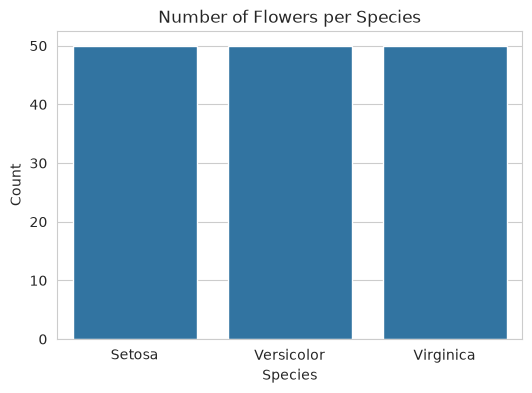

In [46]:
## bar chart: Tpes of Flowers per species.
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="species")
plt.title("Number of Flowers per Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

**Scatter Plot**

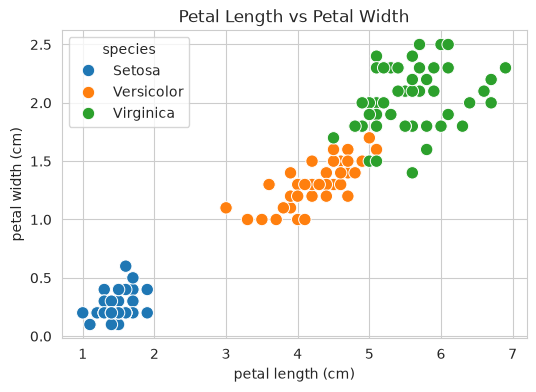

In [47]:
# Scatter Plot: The relationship between petal length and petal width.
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80
)
plt.title("Petal Length vs Petal Width")
plt.show()

*Analysis:* We observe that Setosa is clearly separated to the other clusters ; Versicolor and Virginica overlap a little, but are still distinguishable and visible.

# Machine learning Model

In [48]:
# Prepare Features and Target Variable
# Features (X)
X = df.drop("species", axis=1)

# Target (y)
y = df["species"]

print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    Setosa
1    Setosa
2    Setosa
3    Setosa
4    Setosa
Name: species, dtype: str


In [49]:
# split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (120, 4)
Testing data : (30, 4)


That means : 120 flowers are used to train the model and 30 flowers are used to evaluate it.

# Decision Tree Classifier

In [50]:
# Train the decision tree classifier
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [51]:
# Make Predictions
y_pred = model.predict(X_test)

print(y_pred[:10])

['Versicolor' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa'
 'Versicolor' 'Virginica' 'Versicolor' 'Versicolor']


*Analysis*: The model predicts the species for the test data as presented above.

In [52]:
# Measure accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


# Confusion Matrix

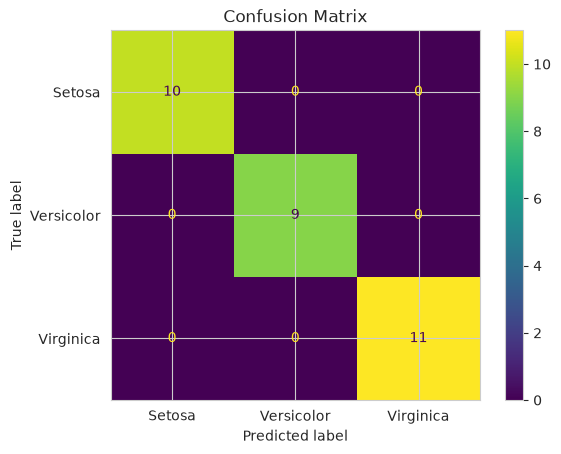

In [53]:
# Display the confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Classification report

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Model comparison

**Train a Random Forest Classifier**

In [55]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [56]:
# Make a decision
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

['Versicolor' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa'
 'Versicolor' 'Virginica' 'Versicolor' 'Versicolor']


In [57]:
# Evaluate the model
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 100.00%


In [58]:
# Classification Report
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 100.00%


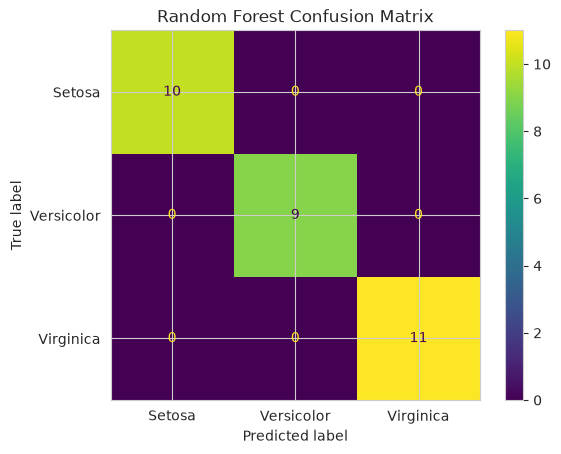

In [59]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

**Compare both Models**

In [60]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0


**Vizualise the comparison**

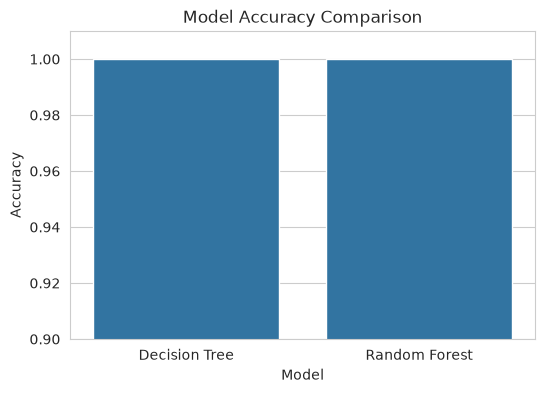

In [61]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.9, 1.01)
plt.title("Model Accuracy Comparison")

plt.show()

**Analysis about the two models**: 
- Decision Tree is simple, easy to interpret, and fast to train. However, it can overfit the training data.
- Random Forest combines multiple Decision Trees, making it more robust and less prone to overfitting. Although both models achieved 100% accuracy on the Iris dataset, Random Forest is generally considered more reliable for larger and more complex datasets.
